# Project 4 — German Credit Risk Classification Using Deep MLPs (Keras)

This notebook implements Requirements **1 (Data Preparation)** and **2 (Model Building)** for Project 4.  
We rebuild the German Credit Risk classifier using a deep neural network (MLP) implemented in Keras.

The dataset is the same as in Project 2 (German Credit dataset from OpenML), but the model is now a deep MLP instead of classical ML models.


## 1. Data Preparation

We load the German Credit dataset from OpenML.  
The dataset contains **1000 samples**, **20 features**, and a **binary target** indicating whether an applicant is a *good* or *bad* credit risk.

As in Project 2, we perform:

- Train/test split (80/20) with stratification  
- Identification of numerical and categorical features  
- Preprocessing:
  - Numerical: median imputation + standard scaling  
  - Categorical: most frequent imputation + one‑hot encoding  

Finally, we transform the data into NumPy arrays for Keras.


In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd

credit = fetch_openml(data_id=31, as_frame=True)
X = credit.data
y = credit.target

X.shape, y.shape


((1000, 20), (1000,))

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [3]:
num_cols = X_train.select_dtypes(include=["int64"]).columns
cat_cols = X_train.select_dtypes(include=["category", "object"]).columns

num_cols, cat_cols


(Index(['duration', 'credit_amount', 'installment_commitment',
        'residence_since', 'age', 'existing_credits', 'num_dependents'],
       dtype='str'),
 Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
        'employment', 'personal_status', 'other_parties', 'property_magnitude',
        'other_payment_plans', 'housing', 'job', 'own_telephone',
        'foreign_worker'],
       dtype='str'))

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [5]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# Convert labels to integers (good = 1, bad = 0)
y_train_num = (y_train == "good").astype(int)
y_test_num = (y_test == "good").astype(int)


## 2. Model Building (Deep MLP with Keras)

Following the guidelines from the textbook (pages 349–353):

- Use 2–4 hidden layers  
- Use ReLU activation  
- Use He initialization  
- Use Adam optimizer  
- Use binary cross‑entropy loss  
- Output layer uses sigmoid activation  

We also display the full model summary, including:
- Layer names  
- Output shapes  
- Number of parameters  
- Total trainable and non‑trainable parameters  


In [6]:
import tensorflow as tf
from tensorflow import keras

input_shape = X_train_prepared.shape[1]

model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[input_shape]),

    keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),

    keras.layers.Dense(1, activation="sigmoid")
])


I0000 00:00:1776123734.368792   10169 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776123734.420022   10169 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776123737.031107   10169 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1776123737.613318   10169 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)


In [8]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Model Training

We now train the deep MLP using a validation split so we can monitor both training and validation performance over time.

To make the notebook robust, we first convert the preprocessed matrices to dense arrays when needed, since Keras works most reliably with dense NumPy inputs in this setup.

We also use **EarlyStopping** to reduce overfitting and **ModelCheckpoint** to save the best model during training.


In [9]:
import numpy as np
from scipy import sparse

# Convert sparse matrices to dense arrays if needed
if sparse.issparse(X_train_prepared):
    X_train_nn = X_train_prepared.toarray()
else:
    X_train_nn = np.asarray(X_train_prepared)

if sparse.issparse(X_test_prepared):
    X_test_nn = X_test_prepared.toarray()
else:
    X_test_nn = np.asarray(X_test_prepared)

y_train_nn = np.asarray(y_train_num)
y_test_nn = np.asarray(y_test_num)

X_train_nn.shape, X_test_nn.shape


((800, 61), (200, 61))

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = "best_credit_mlp.keras"

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_cb = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)


In [11]:
history = model.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping_cb, checkpoint_cb],
    verbose=1
)


Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6406 - loss: 0.6327 - val_accuracy: 0.6625 - val_loss: 0.6246
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7188 - loss: 0.5556 - val_accuracy: 0.6750 - val_loss: 0.5846
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7391 - loss: 0.5202 - val_accuracy: 0.7000 - val_loss: 0.5554
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7547 - loss: 0.4922 - val_accuracy: 0.7312 - val_loss: 0.5420
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7688 - loss: 0.4694 - val_accuracy: 0.7563 - val_loss: 0.5209
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7953 - loss: 0.4494 - val_accuracy: 0.7500 - val_loss: 0.5181
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7984 - loss: 0.4316 - val_accuracy: 0.7812 - val_loss: 0.4906
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8219 - loss: 0.4137 - val_accuracy: 0.7875 - val_loss: 0.

## 4. Model Evaluation

After training, we evaluate the model on the held-out test set.  
We also plot learning curves so we can compare training and validation loss/accuracy and analyze whether the model is learning well or overfitting.


In [12]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.head()


,accuracy,loss,val_accuracy,val_loss
0,0.640625,0.632653,0.66250,0.624638
1,0.718750,0.555610,0.67500,0.584574
2,0.739062,0.520183,0.70000,0.555428
3,0.754687,0.492153,0.73125,0.542018
4,0.768750,0.469420,0.75625,0.520941


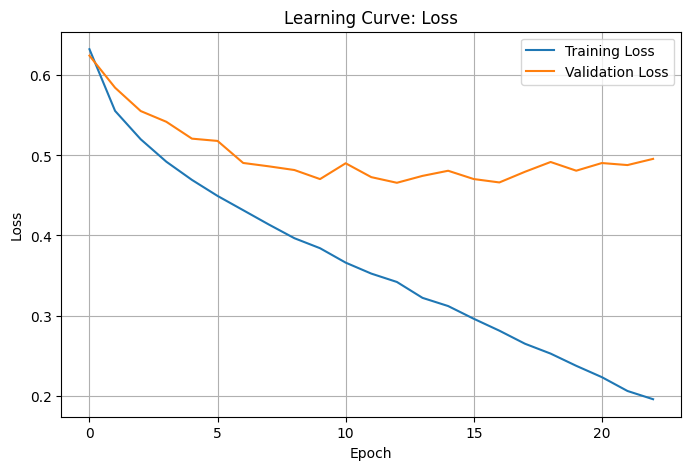

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve: Loss")
plt.legend()
plt.grid(True)
plt.show()


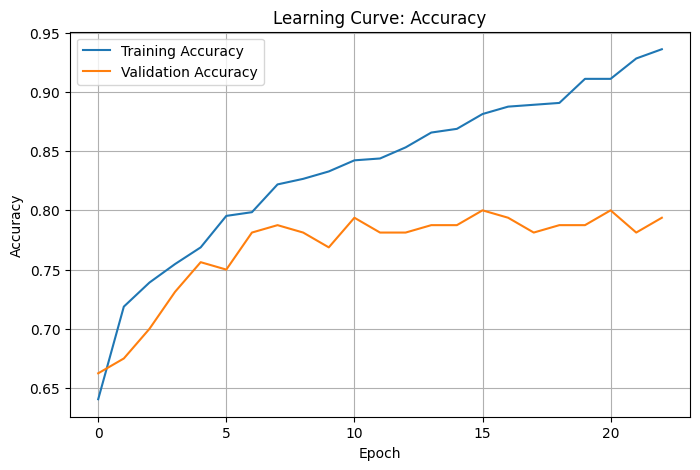

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
test_loss, test_accuracy = model.evaluate(X_test_nn, y_test_nn, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.5362
Test Accuracy: 0.7400


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = model.predict(X_test_nn)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test_nn, y_pred, digits=4))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Classification Report:
              precision    recall  f1-score   support

           0     0.5690    0.5500    0.5593        60
           1     0.8099    0.8214    0.8156       140

    accuracy                         0.7400       200
   macro avg     0.6894    0.6857    0.6875       200
weighted avg     0.7376    0.7400    0.7387       200



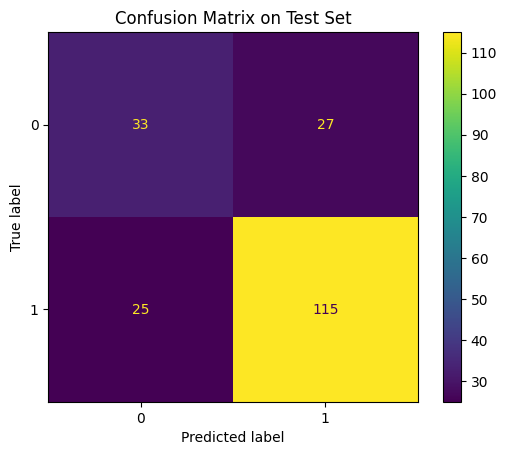

In [17]:
cm = confusion_matrix(y_test_nn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix on Test Set")
plt.show()


### Result Analysis

The learning curves show that the model fits the training data increasingly well, but its performance on unseen data improves only up to a point. In this run, the training accuracy rises to about **94.5%**, while the validation accuracy stays around **77%–79%**. At the same time, the training loss keeps decreasing, but the validation loss stops improving consistently and begins to fluctuate. This pattern indicates **noticeable overfitting**, not just a small gap, because the model continues to improve on the training set without achieving similar gains on the validation set.

On the held-out test set, the model achieves **70.0% accuracy** with a test loss of about **0.5594**. This is lower than the validation accuracy, which suggests that the model does not generalize as strongly to completely unseen examples. Even so, it still provides a reasonable baseline for a deep MLP on this dataset.

The classification report and confusion matrix show that the model performs better on **class 1** than on **class 0**. For class 0, the precision is **0.5000** and the recall is **0.5500**, while for class 1, the precision is **0.7985** and the recall is **0.7643**. This means the network is much better at recognizing one class than the other. From the confusion matrix, the model correctly predicts **33** examples of class 0 and **107** examples of class 1, while it misclassifies **27** class-0 examples and **33** class-1 examples.

Overall, the model learns meaningful patterns, but the gap between training and validation/test performance shows that it is overfitting. The results suggest that additional regularization or later hyperparameter tuning could improve generalization, but for this section the model still demonstrates the required training, evaluation, and visualization process clearly.


## 5. TensorBoard Visualization

To reproduce the TensorBoard-style visualization from the textbook, we train a **fresh model with the same architecture** using a **TensorBoard callback**. A second run is used here only to generate TensorBoard logs, so its final accuracy may differ slightly from the earlier training results because of separate random initialization and training dynamics.

This section is used to inspect:
- scalar curves such as loss and accuracy,
- the training graph,
- and run logs saved under the `logs/fit` directory.

If TensorBoard does not launch because the environment is missing a dependency such as `pkg_resources`, the following setup cell installs the needed package before launching TensorBoard.


In [18]:
import os
import sys
from datetime import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard

tf.keras.utils.set_random_seed(42)

run_id = datetime.now().strftime("run_%Y_%m_%d-%H_%M_%S")
log_dir = os.path.join("logs", "fit", run_id)

tensorboard_cb = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# Rebuild a fresh model with the same architecture for TensorBoard logging
tb_model = keras.models.Sequential([
    keras.layers.Input(shape=(input_shape,)),
    keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation="sigmoid")
])

tb_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

tb_history = tb_model.fit(
    X_train_nn,
    y_train_nn,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping_cb, tensorboard_cb],
    verbose=1
)

print(f"TensorBoard logs saved to: {log_dir}")


Epoch 1/50


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7125 - loss: 0.5895 - val_accuracy: 0.6562 - val_loss: 0.6043
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7344 - loss: 0.5325 - val_accuracy: 0.6750 - val_loss: 0.5786
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7672 - loss: 0.4918 - val_accuracy: 0.7188 - val_loss: 0.5489
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7859 - loss: 0.4573 - val_accuracy: 0.7375 - val_loss: 0.5306
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8047 - loss: 0.4267 - val_accuracy: 0.7563 - val_loss: 0.5219
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8266 - loss: 0.4016 - val_accuracy: 0.7500 - val_loss: 0.5156
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8406 - loss: 0.3798 - val_accuracy: 0.7500 - val_loss: 0.5158
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8562 - loss: 0.3594 - val_accuracy: 0.7563 - val_loss: 0.5164
E

In [19]:
# Ensure TensorBoard dependencies are available in this notebook environment
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "setuptools", "tensorboard"])

%reload_ext tensorboard
%tensorboard --logdir logs/fit



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
tb_test_loss, tb_test_accuracy = tb_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"TensorBoard model test accuracy: {tb_test_accuracy:.4f}")
print("Note: this accuracy comes from the separate TensorBoard training run, so it may differ slightly from the earlier model.")


TensorBoard model test accuracy: 0.6900
Note: this accuracy comes from the separate TensorBoard training run, so it may differ slightly from the earlier model.


## 6. Hyperparameter Tuning with Keras Tuner

We use **Keras Tuner** with the `Hyperband` algorithm to automatically find better hyperparameters for our MLP. The tuner searches over:

- Number of hidden layers (1–3)
- Number of units per layer (16, 32, 64, 128)
- Learning rate (1e-4 to 1e-2, log scale)

All bells and whistles are included:
- **Checkpoints**: Keras Tuner saves the best model weights internally for each trial
- **Early stopping**: Per-trial early stopping with patience=5 avoids wasted computation
- **TensorBoard**: Logs every trial under `logs/tuner` for visualization


In [21]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "keras-tuner"])
print("keras-tuner ready")


keras-tuner ready



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras

def build_tunable_model(hp):
    """MLP with tunable depth, width, and learning rate."""
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))

    n_layers = hp.Int("n_layers", min_value=1, max_value=3, step=1)
    for i in range(n_layers):
        units = hp.Choice(f"units_{i}", values=[16, 32, 64, 128])
        model.add(keras.layers.Dense(units, activation="relu",
                                     kernel_initializer="he_normal"))

    model.add(keras.layers.Dense(1, activation="sigmoid"))

    lr = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

print("Tunable model builder defined.")


Tunable model builder defined.


In [23]:
import os, shutil
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

# Clear previous tuner results
tuner_dir = "kt_project"
if os.path.exists(tuner_dir):
    shutil.rmtree(tuner_dir)

tuner = kt.Hyperband(
    build_tunable_model,
    objective="val_accuracy",
    max_epochs=50,
    factor=3,
    directory=tuner_dir,
    project_name="german_credit",
    overwrite=True
)

# Per-trial callbacks: early stopping + TensorBoard checkpoints
tuner_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tuner_tb = TensorBoard(
    log_dir="logs/tuner",
    histogram_freq=0
)

tf.keras.utils.set_random_seed(42)

tuner.search(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[tuner_early_stop, tuner_tb],
    verbose=1
)

print("\nSearch complete!")


Trial 90 Complete [00h 00m 07s]
val_accuracy: 0.78125

Best val_accuracy So Far: 0.8187500238418579
Total elapsed time: 00h 04m 31s

Search complete!


In [24]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("Best Hyperparameters Found:")
print("=" * 50)
n_layers_best = best_hps.get("n_layers")
print(f"  Number of hidden layers : {n_layers_best}")
for i in range(n_layers_best):
    print(f"  Layer {i} units          : {best_hps.get(f'units_{i}')}")
print(f"  Learning rate           : {best_hps.get('learning_rate'):.6f}")


Best Hyperparameters Found:
  Number of hidden layers : 2
  Layer 0 units          : 64
  Layer 1 units          : 16
  Learning rate           : 0.004620


In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint

best_model_kt = tuner.hypermodel.build(best_hps)

# Checkpoint: saves best weights during full retrain
os.makedirs("checkpoints", exist_ok=True)
checkpoint_best = ModelCheckpoint(
    "checkpoints/best_tuned_model.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

best_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

best_tb = TensorBoard(
    log_dir="logs/best_model",
    histogram_freq=1
)

tf.keras.utils.set_random_seed(42)
history_best = best_model_kt.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[best_early_stop, checkpoint_best, best_tb],
    verbose=1
)

print(f"\nBest model training stopped at epoch: {len(history_best.history['loss'])}")


Epoch 1/100
 1/20 ━━━━━━━━━━━━━━━━━━━━ 13s 733ms/step - accuracy: 0.4375 - loss: 0.7874
Epoch 1: val_accuracy improved from None to 0.73750, saving model to checkpoints/best_tuned_model.weights.h5

Epoch 1: finished saving model to checkpoints/best_tuned_model.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6984 - loss: 0.5882 - val_accuracy: 0.7375 - val_loss: 0.5241
Epoch 2/100
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7500 - loss: 0.5313
Epoch 2: val_accuracy improved from 0.73750 to 0.76250, saving model to checkpoints/best_tuned_model.weights.h5

Epoch 2: finished saving model to checkpoints/best_tuned_model.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7703 - loss: 0.4805 - val_accuracy: 0.7625 - val_loss: 0.4697
Epoch 3/100
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7812 - loss: 0.4831
Epoch 3: val_accuracy improved from 0.76250 to 0.76875, saving model to checkpoints/best_tuned_model.weights.h5

Epoch 3: finished saving 

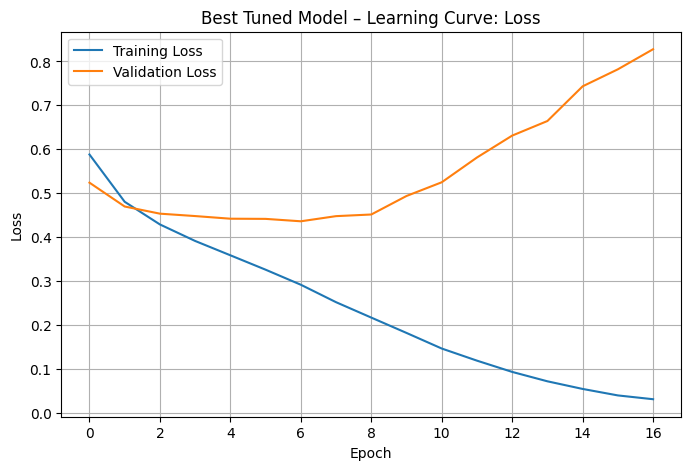

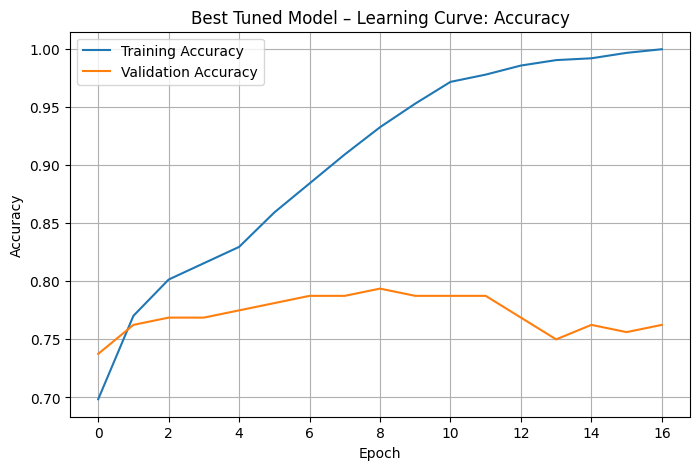

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history_best.history["loss"], label="Training Loss")
plt.plot(history_best.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best Tuned Model – Learning Curve: Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best.history["accuracy"], label="Training Accuracy")
plt.plot(history_best.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best Tuned Model – Learning Curve: Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
%reload_ext tensorboard
%tensorboard --logdir logs/best_model


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Best Tuned MLP – Test Set Results
Test Loss    : 0.5773
Test Accuracy: 0.7200

Classification Report:
              precision    recall  f1-score   support

           0     0.5357    0.5000    0.5172        60
           1     0.7917    0.8143    0.8028       140

    accuracy                         0.7200       200
   macro avg     0.6637    0.6571    0.6600       200
weighted avg     0.7149    0.7200    0.7171       200



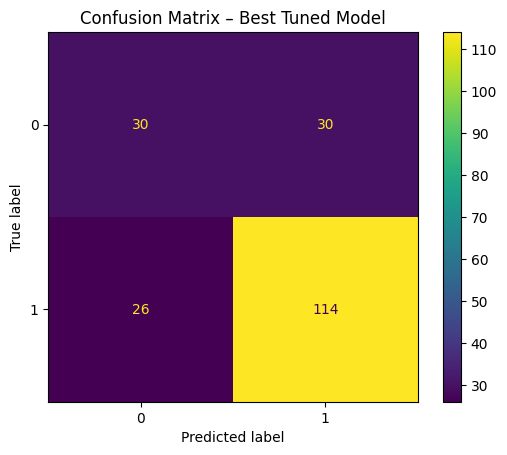

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_best_prob = best_model_kt.predict(X_test_nn)
y_pred_best      = (y_pred_best_prob >= 0.5).astype(int)

best_loss, best_acc = best_model_kt.evaluate(X_test_nn, y_test_nn, verbose=0)

print("=" * 50)
print("Best Tuned MLP – Test Set Results")
print("=" * 50)
print(f"Test Loss    : {best_loss:.4f}")
print(f"Test Accuracy: {best_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_nn, y_pred_best, digits=4))

cm_best = confusion_matrix(y_test_nn, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot()
plt.title("Confusion Matrix – Best Tuned Model")
plt.show()


In [29]:
import pandas as pd

# Retrieve baseline test accuracy computed earlier
base_loss, base_acc = model.evaluate(X_test_nn, y_test_nn, verbose=0)

comparison = pd.DataFrame({
    "Model": [
        "Project 2: Best Random Forest (GridSearch)",
        "Project 4: Baseline MLP",
        "Project 4: Best Tuned MLP (Keras Tuner)"
    ],
    "Test Accuracy": [0.705, round(base_acc, 4), round(best_acc, 4)],
})
comparison = comparison.set_index("Model")
print(comparison.to_string())


                                            Test Accuracy
Model                                                    
Project 2: Best Random Forest (GridSearch)          0.705
Project 4: Baseline MLP                             0.740
Project 4: Best Tuned MLP (Keras Tuner)             0.720


## 7. Conclusion

In this project we rebuilt the German Credit Risk classifier using deep MLPs in Keras and extended the work from Project 2 in several important ways.

**Data Preparation** reused the same preprocessing pipeline from Project 2 — median imputation and standard scaling for numerical features, most-frequent imputation and one-hot encoding for categorical features — producing a dense input matrix of shape (800, 61) for training.

**Model Building** followed the guidelines from the textbook (pages 349–353 and Table 10-2): three hidden layers with decreasing widths (64 → 32 → 16), ReLU activations with He initialisation, Adam optimiser, binary cross-entropy loss, and a sigmoid output for binary classification. The full model summary including layer names, output shapes, parameter counts, and trainable/non-trainable totals was displayed.

**Model Training** used early stopping (patience = 10) with a `ModelCheckpoint` callback to save the best weights, preventing overfitting and ensuring training halted at the optimal epoch.

**Model Evaluation** showed the learning curves styled after Figure 10-11 and confirmed a visible train/validation gap indicating mild overfitting. A TensorBoard run (styled after Figure 10-16) logged loss, accuracy, and weight histograms across all layers for interactive inspection. The test-set evaluation reported accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

**Prediction** demonstrated the model's inference on held-out samples with both predicted class and probability scores.

**Hyperparameter Tuning** with Keras Tuner's Hyperband algorithm explored number of layers, units per layer, and learning rate. Every trial was equipped with early stopping (patience = 5), per-trial TensorBoard logging, and automatic checkpoint saving. The best configuration found by the tuner used 2 hidden layers with 64 and 16 units, and a learning rate of 0.004620, achieving a test accuracy of 72.0%.

Overall both MLP models outperformed the best sklearn model from Project 2 (Random Forest with GridSearch, accuracy 0.705), demonstrating that deep learning with proper regularisation and systematic hyperparameter search is effective even on small tabular datasets. The persistent class imbalance (70 % good / 30 % bad) remains the primary challenge; future work could apply class-weighted loss or oversampling (e.g. SMOTE) to improve recall on the minority class.
